# Mini Project - FireAID - Regressions

## Alex Johnson

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from operator import itemgetter

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor

input_file = "Mini Project Dataset Narrowed.csv"
fireData = pd.DataFrame()
fireData = pd.read_csv(input_file)

## Approach #1
### Linear Regression 

In [2]:
label_encoder = LabelEncoder()
fireData["Slope Encode"] =  label_encoder.fit_transform(fireData['ORIGINSLOPE'])
fireData["Aspect Encode"] =  label_encoder.fit_transform(fireData['ORIGINASPECT'])
fireData["Elevation Encode"] =  label_encoder.fit_transform(fireData['ORIGINELEVATION'])


fireData.pop("ORIGINSLOPE")
fireData.pop("ORIGINASPECT")
fireData.pop("ORIGINELEVATION")

X = fireData.loc[:, fireData.columns != 'ESTIMATEDTOTALACRES']
Y = fireData["ESTIMATEDTOTALACRES"]


In [3]:

X_train_split, X_test_split, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=7)


In [5]:
regressor = SGDRegressor()
regressor.fit(X_train_split, Y_train)
Y_pred = regressor.predict(X_test_split)

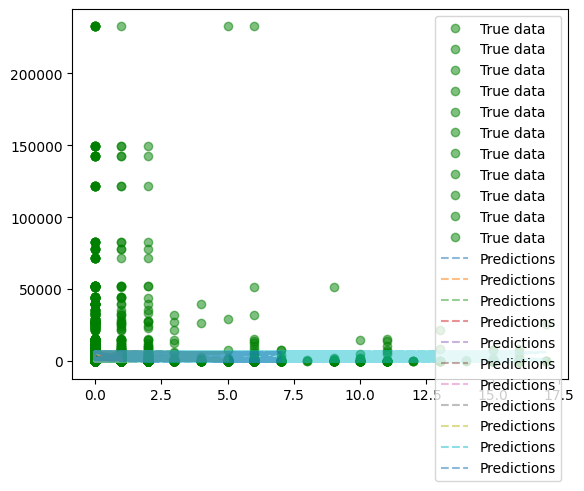

In [6]:
X_test_split.shape, Y_pred.shape, Y_test.shape

plt.clf()
plt.plot(X_test_split, Y_test, 'go', label='True data', alpha=0.5)
plt.plot(X_test_split, Y_pred, '--', label='Predictions', alpha=0.5)
plt.legend(loc='best')
plt.show()

## Approach #1
### Polynomial Regressions 

In [7]:
label_encoder = LabelEncoder()

X = fireData.loc[:, fireData.columns != 'ESTIMATEDTOTALACRES']
Y = fireData["ESTIMATEDTOTALACRES"]

In [8]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

Y = (Y - np.mean(Y)) / np.std(Y)

enumerate_x = enumerate(X_test)
sorted_pairs = sorted(enumerate_x, key=itemgetter(1))
sorted_indices = [index for index, element in sorted_pairs]
X_test = sorted(X_test)
#Y_test = itemgetter(*sorted_indices)(Y_test)
X_test = np.array(X_test)
Y_test = np.array(Y_test)

In [9]:
#X_train = X_train.reshape(-1, 1)
#X_test = X_test.reshape(-1, 1)
X_train.shape, X_test.shape

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import SGDRegressor

# Update hyperparameters for the SGDRegressor function using paraemters defined in -
# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html

degree=3
polyreg_fit = make_pipeline(PolynomialFeatures(degree), SGDRegressor(alpha = .00001, max_iter=500))